# 02c — Backbone y Clasificacion v3

**Diferencias respecto a v2**

- `CAPAS_DESCONGELAR` aumentado de 50 a 100 — fine-tuning sobre más capas
  del backbone para adaptar más representaciones a imágenes médicas.
- `LR_FASE_2` mantenido en 1e-5 (no 3e-5) — con 100 capas descongeladas,
  un LR más alto puede sobreescribir los pesos preentrenados de ImageNet.
- `MONITOR_METRICA = "val_auc"` — los callbacks monitorizan AUC en lugar
  de val_loss. En v2, val_loss eligió un checkpoint con peor AUC que el
  epoch siguiente; AUC es la métrica que realmente importa.
- `factor=0.3` en ReduceLROnPlateau — en v2, factor=0.1 llevó el LR de
  1e-5 a 1e-6 en un solo disparo (época 5 de Fase 2) y el aprendizaje
  se detuvo. Con 0.3 la caída es más gradual.
- `PACIENCIA_EARLY` aumentada de 5 a 8 — evita corte prematuro durante
  el fine-tuning con 100 capas.
- `EPOCHS_FASE_2` aumentado de 15 a 20 — más margen para converger.
- Checkpoints separados por fase (`_f1` y `_f2`) — permite reanudar en
  cualquier estado: sin checkpoint, con Fase 1 completa, o con Fase 2
  parcialmente completada. La lógica de detección tiene tres estados.
- `BatchNormalization` añadida a la cabeza — estabiliza la distribución
  de activaciones durante el fine-tuning con más capas descongeladas.
- Data augmentation conservador (flip, rotación ±5°, zoom 5%).
- Calibración de umbral sobre validación antes de evaluar en test.

**Archivos que produce este notebook**
- `Vena/checkpoints/mejor_modelo_clasificacion_v3_f1.keras`
- `Vena/checkpoints/mejor_modelo_clasificacion_v3_f2.keras`
- `Vena/checkpoints/backbone_densenet121_v3.h5`
- `Vena/checkpoints/curvas_entrenamiento_clasificacion_v3.png`
- `Vena/checkpoints/matriz_confusion_clasificacion_v3.png`

## Celda 1 — Verificacion de GPU

Lo primero que se hace en cada sesion es confirmar que Colab asigno una GPU.
Si esta celda muestra 'No se encontro GPU', detener aqui y cambiar el tipo de
entorno de ejecucion antes de continuar. Entrenar en CPU es entre 10 y 50 veces
mas lento y la sesion de Colab se agotara antes de terminar un solo epoch.

In [11]:
import tensorflow as tf

gpus_disponibles = tf.config.list_physical_devices('GPU')

if gpus_disponibles:
    print(f"GPU encontrada: {gpus_disponibles[0].name}")
    print("El entrenamiento usara aceleracion por GPU.")
else:
    print("No se encontro GPU.")
    print("Ir a: Entorno de ejecucion > Cambiar tipo de entorno > GPU")
    print("Detener la ejecucion hasta resolver esto.")

GPU encontrada: /physical_device:GPU:0
El entrenamiento usara aceleracion por GPU.


## Celda 2 — Montar Google Drive y definir rutas

Se definen todas las rutas del proyecto desde un solo lugar.
Usa nih_clean.csv en lugar de master.csv + Data_Entry_2017.csv.

In [12]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

ruta_vena        = Path("/content/drive/MyDrive/Vena")
ruta_datasets    = ruta_vena / "Notebooks" / "Datasets"
ruta_checkpoints = ruta_vena / "checkpoints"
ruta_checkpoints.mkdir(parents=True, exist_ok=True)

ruta_nih_clean   = ruta_datasets / "nih_clean.csv"
ruta_zip_nih     = ruta_datasets / "nih_resized_224.zip"
ruta_zip_chest   = ruta_datasets / "chest_xray.zip"

assert ruta_nih_clean.exists(), f"No se encontro nih_clean.csv en {ruta_nih_clean}"
assert ruta_zip_nih.exists(),   f"No se encontro nih_resized_224.zip en {ruta_zip_nih}"
assert ruta_zip_chest.exists(), f"No se encontro chest_xray.zip en {ruta_zip_chest}"

print("Drive montado correctamente.")
print(f"Checkpoints en: {ruta_checkpoints}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado correctamente.
Checkpoints en: /content/drive/MyDrive/Vena/checkpoints


## Celda 3 — Importaciones y parametros de configuracion

Todos los hiperparametros en un solo lugar.

Cambios respecto a v2:
- `MONITOR_METRICA`: todos los callbacks usan val_auc en lugar de val_loss.
  En v2 el checkpoint guardaba el modelo con peor AUC porque priorizaba
  val_loss. AUC mide directamente la capacidad discriminativa del modelo.
- `LR_FASE_2 = 1e-5`: v3 proponia 3e-5, pero con 100 capas descongeladas
  un LR 3x mayor al de v2 puede destruir features preentrenadas.
- `FACTOR_LR = 0.3`: en v2 factor=0.1 apago el aprendizaje de golpe en
  la epoca 5 de Fase 2 (LR paso de 1e-5 a 1e-6). Con 0.3 es mas gradual.
- Nombres de checkpoint separados por fase para reanudar correctamente.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import subprocess
import time
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             classification_report, f1_score)
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                     Dropout, BatchNormalization)
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                        ReduceLROnPlateau)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ── Hiperparametros ──────────────────────────────────────────────────────────
TAMANO_IMAGEN     = 224
BATCH_SIZE        = 16
EPOCHS_FASE_1     = 10
EPOCHS_FASE_2     = 20
CAPAS_DESCONGELAR = 100
LR_FASE_1         = 1e-3
LR_FASE_2         = 1e-5    # v3 proponia 3e-5; con 100 capas descongeladas
                             # es peligroso — se mantiene el valor de v2
FACTOR_LR         = 0.3     # v2 usaba 0.1 y mato el aprendizaje de golpe
PACIENCIA_EARLY   = 8
SEMILLA           = 42

# ── Metrica de monitoreo ─────────────────────────────────────────────────────
# "val_auc": AUC mide la capacidad discriminativa independientemente del umbral.
# En v2, monitorizar val_loss guardo un checkpoint con peor AUC que el epoch
# siguiente porque loss y AUC no siempre se mueven en la misma direccion.
MONITOR_METRICA   = "val_auc"   # los callbacks maximizan esta metrica
MONITOR_MODE      = "max"       # AUC se maximiza (loss se minimiza)

# ── Nombres de archivos ───────────────────────────────────────────────────────
# Dos checkpoints separados: uno por fase. Permite reanudar exactamente
# desde el estado correcto independientemente de cuando se corto la sesion.
NOMBRE_MODELO_F1  = "mejor_modelo_clasificacion_v3_f1.keras"
NOMBRE_MODELO_F2  = "mejor_modelo_clasificacion_v3_f2.keras"
NOMBRE_BACKBONE   = "backbone_densenet121_v3.h5"
NOMBRE_CURVAS     = "curvas_entrenamiento_clasificacion_v3.png"
NOMBRE_MATRIZ     = "matriz_confusion_clasificacion_v3.png"

np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print("Configuracion cargada.")
print(f"  Tamano de imagen    : {TAMANO_IMAGEN}x{TAMANO_IMAGEN} px")
print(f"  Batch size          : {BATCH_SIZE}")
print(f"  Epochs fase 1       : {EPOCHS_FASE_1}")
print(f"  Epochs fase 2       : {EPOCHS_FASE_2}")
print(f"  Capas descongeladas : {CAPAS_DESCONGELAR}")
print(f"  LR fase 1 / fase 2  : {LR_FASE_1} / {LR_FASE_2}")
print(f"  Factor ReduceLR     : {FACTOR_LR}")
print(f"  Metrica monitoreo   : {MONITOR_METRICA}")
print(f"  Checkpoint fase 1   : {NOMBRE_MODELO_F1}")
print(f"  Checkpoint fase 2   : {NOMBRE_MODELO_F2}")

Configuracion cargada.
  Tamano de imagen    : 224x224 px
  Batch size          : 16
  Epochs fase 1       : 10
  Epochs fase 2       : 20
  Capas descongeladas : 100
  LR fase 1 / fase 2  : 0.001 / 1e-05
  Factor ReduceLR     : 0.3
  Metrica monitoreo   : val_auc
  Checkpoint fase 1   : mejor_modelo_clasificacion_v3_f1.keras
  Checkpoint fase 2   : mejor_modelo_clasificacion_v3_f2.keras


## Celda 4 — Descomprimir datasets al disco local

Drive tiene latencia alta al leer miles de archivos pequenos en paralelo.
La solucion es tener los datasets como zip en Drive y descomprimirlos al
disco local de Colab al inicio de cada sesion. Descomprimir es una sola
operacion de lectura secuencial que tarda 2-5 minutos.

El disco local de Colab es temporal — desaparece al cerrar la sesion.
Los checkpoints del modelo se guardan en Drive y persisten entre sesiones.

In [14]:
ruta_local_nih   = Path("/content/nih_resized_224")
ruta_local_chest = Path("/content/chest_xray")
RUTA_LOCAL_NIH   = ruta_local_nih

# --- Descomprimir NIH ---
imagenes_nih = [p for p in RUTA_LOCAL_NIH.glob("*")
                if p.suffix.lower() == ".png"] if RUTA_LOCAL_NIH.exists() else []
if len(imagenes_nih) > 1000:
    print(f"NIH ya en disco local: {len(imagenes_nih):,} imagenes. Saltando.")
else:
    print("Descomprimiendo NIH... (2-5 minutos)")
    inicio = time.time()
    subprocess.run(f"unzip -q {ruta_zip_nih} -d /content/", shell=True)
    imagenes_nih = [p for p in RUTA_LOCAL_NIH.glob("*")
                    if p.suffix.lower() == ".png"]
    print(f"NIH listo en {(time.time()-inicio)/60:.1f} min — {len(imagenes_nih):,} imagenes")

# --- Descomprimir Chest X-Ray ---
n_chest = len(list(ruta_local_chest.rglob("*.jpeg"))) if ruta_local_chest.exists() else 0
if n_chest > 100:
    print(f"Chest X-Ray ya en disco local: {n_chest:,} imagenes. Saltando.")
else:
    print("Descomprimiendo Chest X-Ray...")
    inicio = time.time()
    subprocess.run(f"unzip -q {ruta_zip_chest} -d /content/", shell=True)
    n_chest = len(list(ruta_local_chest.rglob("*.jpeg")))
    print(f"Chest X-Ray listo en {(time.time()-inicio)/60:.1f} min — {n_chest:,} imagenes")

print("\nDatasets en disco local listos.")

Descomprimiendo NIH... (2-5 minutos)
NIH listo en 0.9 min — 112,120 imagenes
Descomprimiendo Chest X-Ray...
Chest X-Ray listo en 0.4 min — 5,856 imagenes

Datasets en disco local listos.


## Celda 5 — Cargar nih_clean.csv y agregar rutas

Carga el CSV limpio generado por el equipo. Ya tiene las columnas necesarias:
nombre_imagen, tiene_anomalia, patient_id. Solo se agrega la ruta completa
local de cada imagen combinando la carpeta local del NIH con el nombre de archivo.

In [15]:
df_nih = pd.read_csv(ruta_nih_clean)

df_nih["ruta_completa"] = df_nih["nombre_imagen"].apply(
    lambda nombre: str(RUTA_LOCAL_NIH / nombre)
)

print(f"Imagenes PA cargadas : {len(df_nih):,}")
print(f"Pacientes unicos     : {df_nih['patient_id'].nunique():,}")
print(f"\nDistribucion global:")
print(f"  Con anomalia : {df_nih['tiene_anomalia'].sum():,} ({df_nih['tiene_anomalia'].mean()*100:.1f}%)")
print(f"  Sin anomalia : {(df_nih['tiene_anomalia']==0).sum():,} ({(1-df_nih['tiene_anomalia'].mean())*100:.1f}%)")

Imagenes PA cargadas : 67,299
Pacientes unicos     : 28,864

Distribucion global:
  Con anomalia : 28,003 (41.6%)
  Sin anomalia : 39,296 (58.4%)


## Celda 6 — Patient-level split

La division se hace por Patient ID, no por imagen. Esto evita que radiografias
del mismo paciente aparezcan en train y test simultaneamente, lo que infla
artificialmente las metricas porque el modelo aprende rasgos del paciente
en lugar de patrones de patologia.

Se usa la misma semilla (42) y los mismos proporciones que v1 y v2
para mantener consistencia metodologica entre versiones.

In [16]:
pacientes_unicos = df_nih["patient_id"].unique()
print(f"Pacientes unicos: {len(pacientes_unicos):,}")

# Paso 1: separar 15% para test
pacientes_train_val, pacientes_test = train_test_split(
    pacientes_unicos, test_size=0.15, random_state=SEMILLA
)

# Paso 2: del 85% restante, separar ~15% para val (15/85 = 0.176)
pacientes_train, pacientes_val = train_test_split(
    pacientes_train_val, test_size=0.176, random_state=SEMILLA
)

df_train_completo = df_nih[df_nih["patient_id"].isin(pacientes_train)].copy()
df_val            = df_nih[df_nih["patient_id"].isin(pacientes_val)].copy()
df_test_nih       = df_nih[df_nih["patient_id"].isin(pacientes_test)].copy()

print(f"\nSplit completado:")
print(f"  Train : {len(df_train_completo):,} imagenes ({df_train_completo['patient_id'].nunique():,} pacientes)")
print(f"  Val   : {len(df_val):,} imagenes ({df_val['patient_id'].nunique():,} pacientes)")
print(f"  Test  : {len(df_test_nih):,} imagenes ({df_test_nih['patient_id'].nunique():,} pacientes)")

Pacientes unicos: 28,864

Split completado:
  Train : 46,978 imagenes (20,216 pacientes)
  Val   : 10,148 imagenes (4,318 pacientes)
  Test  : 10,173 imagenes (4,330 pacientes)


## Celda 7 — Balanceo del conjunto de entrenamiento

El conjunto de train tiene ~41% anomalas y ~59% normales. Entrenar con ese
desbalance tiende a producir un modelo conservador que predice 'normal' con
mas frecuencia, resultando en sensibilidad baja.

Estrategia:
- Usar TODAS las imagenes anomalas en train (clase minoritaria)
- Submuestrear la clase normal para igualar exactamente ese numero

Nota sobre pesos de clase: dado que el dataset de train queda balanceado
50/50, compute_class_weight("balanced") produce {0: 1.0, 1: 1.0}.
No se pasan pesos a model.fit() porque no tienen efecto sobre un dataset
ya balanceado. Si se quisiera sesgar el modelo (ej. priorizar sensibilidad),
se deberia usar la calibracion de umbral de la Celda 15b en su lugar.

In [17]:
df_anomalas = df_train_completo[df_train_completo["tiene_anomalia"] == 1]
df_normales = df_train_completo[df_train_completo["tiene_anomalia"] == 0].sample(
    n=len(df_anomalas),
    random_state=SEMILLA
)

df_train = pd.concat([df_anomalas, df_normales]).sample(
    frac=1, random_state=SEMILLA
).reset_index(drop=True)

print(f"Train balanceado:")
print(f"  Total        : {len(df_train):,} imagenes")
print(f"  Con anomalia : {df_train['tiene_anomalia'].sum():,} (50%)")
print(f"  Sin anomalia : {(df_train['tiene_anomalia']==0).sum():,} (50%)")
print(f"\nComparacion con versiones anteriores:")
print(f"  v1: 20,000 imagenes de train")
print(f"  v2/v3: {len(df_train):,} imagenes de train (+{len(df_train)-20000:,})")

Train balanceado:
  Total        : 38,810 imagenes
  Con anomalia : 19,405 (50%)
  Sin anomalia : 19,405 (50%)

Comparacion con versiones anteriores:
  v1: 20,000 imagenes de train
  v2/v3: 38,810 imagenes de train (+18,810)


## Celda 8 — Cargar dataset Chest X-Ray para validacion externa

El Chest X-Ray Pneumonia fue recopilado en otro hospital con otro equipo de
rayos X. Evaluarlo permite medir si el modelo aprendio features generalizables
o memorizo rasgos especificos del NIH.

Solo se usa el split test para evaluacion. No se entrena con este dataset.

In [18]:
def construir_df_chest(ruta_split, etiqueta_split):
    """
    Lee las imagenes de una carpeta con subcarpetas NORMAL y PNEUMONIA
    y construye un DataFrame con ruta_completa y tiene_anomalia.
    """
    filas = []
    for clase, etiqueta in [("NORMAL", 0), ("PNEUMONIA", 1)]:
        carpeta = ruta_split / clase
        if not carpeta.exists():
            continue
        for imagen in carpeta.glob("*.jpeg"):
            filas.append({"ruta_completa": str(imagen), "tiene_anomalia": etiqueta})
    df = pd.DataFrame(filas)
    print(f"  {etiqueta_split}: {len(df):,} imagenes")
    return df

ruta_chest = ruta_local_chest

print("Dataset Chest X-Ray Pneumonia:")
df_chest_train = construir_df_chest(ruta_chest / "train", "Train")
df_chest_val   = construir_df_chest(ruta_chest / "val",   "Val")
df_chest_test  = construir_df_chest(ruta_chest / "test",  "Test")

Dataset Chest X-Ray Pneumonia:
  Train: 5,216 imagenes
  Val: 16 imagenes
  Test: 624 imagenes


## Celda 9 — Generadores de datos

Los generadores leen las imagenes del disco en batches durante el entrenamiento.
Para train se aplica augmentation conservador. Para val y test solo se normaliza.

Augmentation para radiografias de torax:
- flip horizontal: el torax es aproximadamente simetrico, es valido
- rotation_range=5: rotaciones mayores son poco realistas clinicamente
- width/height_shift=0.05: simula pequenas variaciones de posicion del paciente
- zoom_range=0.05: simula distintas distancias al detector
- NO flip vertical: una radiografia invertida no tiene sentido clinico

class_mode='raw' es requerido para regresion/clasificacion binaria con
etiquetas numericas en flow_from_dataframe.

In [19]:
gen_train = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=5,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
)
gen_val = ImageDataGenerator(rescale=1./255)

params_flujo = dict(
    x_col="ruta_completa",
    y_col="tiene_anomalia",
    target_size=(TAMANO_IMAGEN, TAMANO_IMAGEN),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

flujo_train = gen_train.flow_from_dataframe(
    df_train,
    x_col="ruta_completa",
    y_col="tiene_anomalia",
    target_size=(TAMANO_IMAGEN, TAMANO_IMAGEN),
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True,
    seed=SEMILLA
)
flujo_val        = gen_val.flow_from_dataframe(df_val,        **params_flujo)
flujo_test_nih   = gen_val.flow_from_dataframe(df_test_nih,   **params_flujo)
flujo_chest_test = gen_val.flow_from_dataframe(df_chest_test, **params_flujo)

print("Generadores creados.")
print(f"  Steps por epoch en train : {len(flujo_train):,}")
print(f"  Steps por epoch en val   : {len(flujo_val):,}")

Found 38810 validated image filenames.
Found 10148 validated image filenames.
Found 10173 validated image filenames.
Found 624 validated image filenames.
Generadores creados.
  Steps por epoch en train : 2,426
  Steps por epoch en val   : 635


## Celda 10 — Definir modelo

Arquitectura base identica a v1 y v2 (DenseNet121 + cabeza),
con un cambio en la cabeza: se agrega BatchNormalization.

- DenseNet121 preentrenado en ImageNet como backbone
- GlobalAveragePooling2D: convierte el mapa de features (7x7x1024) a vector (1024)
- BatchNormalization: normaliza las activaciones antes de la cabeza densa.
  Cuando se descongelan 100 capas en Fase 2, la distribucion de los valores
  que llegan de la cabeza cambia en cada batch. BatchNormalization los
  estabiliza, haciendo el fine-tuning mas robusto ante variaciones de LR.
- Dense(256, relu) + Dropout(0.5): cabeza de clasificacion
- Dense(1, sigmoid): salida para clasificacion binaria

Esta celda SOLO define la arquitectura. Los pesos se manejan en la celda
siguiente segun si existen checkpoints previos.

In [20]:
entrada = tf.keras.Input(shape=(TAMANO_IMAGEN, TAMANO_IMAGEN, 3))

backbone = DenseNet121(
    include_top=False,
    weights="imagenet",
    input_tensor=entrada
)

# Cabeza de clasificacion
# BatchNormalization estabiliza el fine-tuning con 100 capas descongeladas
x = GlobalAveragePooling2D()(backbone.output)
x = BatchNormalization()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
salida = Dense(1, activation="sigmoid")(x)

modelo = Model(inputs=entrada, outputs=salida)

params_totales  = modelo.count_params()
params_backbone = backbone.count_params()
params_cabeza   = params_totales - params_backbone

print("Modelo definido: DenseNet121 + BatchNorm + cabeza de clasificacion")
print(f"  Parametros totales  : {params_totales:,}")
print(f"  Parametros backbone : {params_backbone:,}")
print(f"  Parametros cabeza   : {params_cabeza:,}")

Modelo definido: DenseNet121 + BatchNorm + cabeza de clasificacion
  Parametros totales  : 7,304,257
  Parametros backbone : 7,037,504
  Parametros cabeza   : 266,753


## Celda 11 — Deteccion de checkpoint y preparacion para la fase correcta

Esta celda detecta automaticamente en que estado se encuentra el entrenamiento
y da instrucciones sobre que ejecutar a continuacion.

A diferencia de v2 que tenia un solo archivo de checkpoint, v3 usa dos:
- `_f1.keras`: guardado durante la Fase 1 (cabeza unicamente)
- `_f2.keras`: guardado durante la Fase 2 (fine-tuning del backbone)

Esto permite tres estados de reanudacion:

  Estado 1 — Sin checkpoints (primera sesion, Dia 1):
    Preparar modelo para Fase 1. Ejecutar Celda 12.

  Estado 2 — Solo _f1 existe (Fase 1 completa, Fase 2 pendiente):
    Cargar _f1 y ejecutar Celda 13 (Fase 2).

  Estado 3 — _f2 existe (Fase 2 iniciada, puede estar completa o interrumpida):
    Cargar _f2 y ejecutar Celda 13 de nuevo.
    EarlyStopping terminara rapido si el modelo ya convergio.
    Si habia epocas restantes, continuara desde el mejor punto guardado.

El formato .keras es el nativo de Keras moderno — elimina los warnings de
'formato legacy HDF5' que aparecian en cada guardado de v2.

In [21]:
ruta_modelo_f1 = ruta_checkpoints / NOMBRE_MODELO_F1
ruta_modelo_f2 = ruta_checkpoints / NOMBRE_MODELO_F2

if ruta_modelo_f2.exists():
    # Estado 3: Fase 2 ya inicio (completa o interrumpida)
    print("=" * 55)
    print("ESTADO 3: Checkpoint de Fase 2 encontrado.")
    print("=" * 55)
    modelo = load_model(str(ruta_modelo_f2))
    print(f"Modelo cargado: {ruta_modelo_f2.name}")
    print()
    print("INSTRUCCION: saltar Celda 12 (Fase 1).")
    print("Ejecutar Celda 13 (Fase 2).")
    print("EarlyStopping terminara rapido si ya convergio.")
    print("Si habia epochs restantes, continuara entrenando.")

elif ruta_modelo_f1.exists():
    # Estado 2: Fase 1 completa, Fase 2 pendiente
    print("=" * 55)
    print("ESTADO 2: Checkpoint de Fase 1 encontrado.")
    print("=" * 55)
    modelo = load_model(str(ruta_modelo_f1))
    print(f"Modelo cargado: {ruta_modelo_f1.name}")
    print()
    print("INSTRUCCION: saltar Celda 12 (Fase 1).")
    print("Ejecutar directamente Celda 13 (Fase 2).")

else:
    # Estado 1: sin checkpoints, empezar desde cero
    print("=" * 55)
    print("ESTADO 1: Sin checkpoints. Iniciando desde cero.")
    print("=" * 55)

    # Congelar todo el backbone: solo la cabeza entrena en Fase 1
    backbone.trainable = False

    modelo.compile(
        optimizer=Adam(learning_rate=LR_FASE_1),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    params_entrenables = sum([tf.size(w).numpy() for w in modelo.trainable_weights])
    print(f"  Parametros entrenables (cabeza) : {params_entrenables:,}")
    print(f"  Parametros congelados (backbone): {params_backbone:,}")
    print()
    print("INSTRUCCION: ejecutar Celda 12 (Fase 1) a continuacion.")

ESTADO 3: Checkpoint de Fase 2 encontrado.
Modelo cargado: mejor_modelo_clasificacion_v3_f2.keras

INSTRUCCION: saltar Celda 12 (Fase 1).
Ejecutar Celda 13 (Fase 2).
EarlyStopping terminara rapido si ya convergio.
Si habia epochs restantes, continuara entrenando.


## Celda 12 — Fase 1: entrenar solo la cabeza (Dia 1)

Con el backbone congelado, solo los pesos de la cabeza nueva (BatchNorm +
Dense + Dropout) se actualizan. Esto estabiliza la cabeza antes del fine-tuning.

Si la Celda 11 indico Estado 2 o Estado 3, SALTAR esta celda.
Si la Celda 11 indico Estado 1, ejecutar esta celda.

Callbacks configurados con MONITOR_METRICA = "val_auc" y mode="max":
- ModelCheckpoint: guarda en _f1.keras cuando val_auc mejora
- EarlyStopping: detiene si val_auc no mejora en PACIENCIA_EARLY epochs
- ReduceLROnPlateau: reduce LR con factor=0.3 si val_auc estanca 3 epochs
  (caida gradual, no de golpe como con factor=0.1 de v2)

Al terminar esta celda puedes cerrar Colab. La proxima sesion detectara
automaticamente el checkpoint _f1 y continuara con la Fase 2.

In [ ]:
callbacks_f1 = [
    ModelCheckpoint(
        filepath=str(ruta_modelo_f1),
        monitor=MONITOR_METRICA,
        mode=MONITOR_MODE,
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor=MONITOR_METRICA,
        mode=MONITOR_MODE,
        patience=PACIENCIA_EARLY,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor=MONITOR_METRICA,
        mode=MONITOR_MODE,
        factor=FACTOR_LR,
        patience=3,
        verbose=1
    )
]

print("Iniciando Fase 1: entrenando solo la cabeza (backbone congelado)")
print(f"Epochs maximos : {EPOCHS_FASE_1}")
print(f"Learning rate  : {LR_FASE_1}")
print(f"Monitoreando   : {MONITOR_METRICA} (se guarda cuando mejora)")
print()

historia_fase1 = modelo.fit(
    flujo_train,
    epochs=EPOCHS_FASE_1,
    validation_data=flujo_val,
    callbacks=callbacks_f1,
    verbose=1
)

print()
print("Fase 1 completada.")
print(f"Mejor val_auc  : {max(historia_fase1.history['val_auc']):.4f}")
print(f"Checkpoint guardado en Drive: {NOMBRE_MODELO_F1}")
print()
print("Puedes cerrar Colab. La proxima sesion detectara el checkpoint")
print("y continuara directamente con la Fase 2.")

Iniciando Fase 1: entrenando solo la cabeza (backbone congelado)
Epochs maximos : 10
Learning rate  : 0.001
Monitoreando   : val_auc (se guarda cuando mejora)

Epoch 1/10
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.6141 - auc: 0.6550 - loss: 0.6956
Epoch 1: val_auc improved from None to 0.71552, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v3_f1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v3_f1.keras
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 635s 250ms/step - accuracy: 0.6339 - auc: 0.6774 - loss: 0.6567 - val_accuracy: 0.6732 - val_auc: 0.7155 - val_loss: 0.6109 - learning_rate: 0.0010
Epoch 2/10
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.6544 - auc: 0.7062 - loss: 0.6295
Epoch 2: val_auc improved from 0.71552 to 0.71944, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v3_f1.keras

Epoch 2: finished saving model to /content/drive/

## Celda 13 — Fase 2: fine-tuning del backbone (Dia 2 o posterior)

Se descongelan las ultimas CAPAS_DESCONGELAR (100) capas del backbone para
que el modelo ajuste sus representaciones internas hacia radiografias de torax.

LR_FASE_2 = 1e-5: un LR bajo es esencial en fine-tuning para no destruir
los pesos que DenseNet aprendio en ImageNet. Con 100 capas descongeladas
se necesita igual o menor LR que con 50 (v2), no mayor.

El checkpoint _f2.keras se sobreescribe solo cuando val_auc mejora,
por lo que si Colab corta en medio de esta fase, el mejor punto se conserva.
Al reanudar, la Celda 11 detecta el Estado 3 y carga _f2, luego esta celda
corre con los epochs restantes. EarlyStopping termina rapido si ya convergio.

In [12]:
# Descongelar las ultimas CAPAS_DESCONGELAR capas
# Las capas anteriores permanecen congeladas para no perder features basicas
for capa in modelo.layers[-CAPAS_DESCONGELAR:]:
    capa.trainable = True

# Recompilar con LR bajo para fine-tuning
modelo.compile(
    optimizer=Adam(learning_rate=LR_FASE_2),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

callbacks_f2 = [
    ModelCheckpoint(
        filepath=str(ruta_modelo_f2),   # archivo separado del de Fase 1
        monitor=MONITOR_METRICA,
        mode=MONITOR_MODE,
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor=MONITOR_METRICA,
        mode=MONITOR_MODE,
        patience=PACIENCIA_EARLY,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor=MONITOR_METRICA,
        mode=MONITOR_MODE,
        factor=FACTOR_LR,
        patience=3,
        verbose=1
    )
]

params_entrenables_f2 = sum([tf.size(w).numpy() for w in modelo.trainable_weights])
print(f"Fase 2: {CAPAS_DESCONGELAR} capas descongeladas")
print(f"  Parametros entrenables ahora: {params_entrenables_f2:,}")
print(f"  Learning rate               : {LR_FASE_2}")
print(f"  Monitoreando                : {MONITOR_METRICA}")
print()

historia_fase2 = modelo.fit(
    flujo_train,
    epochs=EPOCHS_FASE_2,
    validation_data=flujo_val,
    callbacks=callbacks_f2,
    verbose=1
)

print()
print("Fase 2 completada.")
print(f"Mejor val_auc fase 2: {max(historia_fase2.history['val_auc']):.4f}")
print(f"Checkpoint guardado en Drive: {NOMBRE_MODELO_F2}")

Fase 2: 100 capas descongeladas
  Parametros entrenables ahora: 2,138,177
  Learning rate               : 1e-05
  Monitoreando                : val_auc

Epoch 1/20
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.6681 - auc: 0.7230 - loss: 0.6181
Epoch 1: val_auc improved from None to 0.72530, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v3_f2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v3_f2.keras
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 732s 277ms/step - accuracy: 0.6715 - auc: 0.7255 - loss: 0.6154 - val_accuracy: 0.6794 - val_auc: 0.7253 - val_loss: 0.6107 - learning_rate: 1.0000e-05
Epoch 2/20
2426/2426 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.6726 - auc: 0.7308 - loss: 0.6093
Epoch 2: val_auc improved from 0.72530 to 0.72777, saving model to /content/drive/MyDrive/Vena/checkpoints/mejor_modelo_clasificacion_v3_f2.keras

Epoch 2: finished saving model to /content/drive/MyD

## Celda 14 — Curvas de entrenamiento

Las curvas permiten diagnosticar el entrenamiento visualmente.
La linea vertical separa la Fase 1 de la Fase 2.

Si ambas fases se corrieron en la misma sesion, se grafican juntas.
Si se corrieron en sesiones distintas, solo estara disponible el historial
de la fase que se ejecuto en la sesion actual — se grafica esa sola.

In [2]:
def graficar_una_fase(historia, titulo_fase):
    """Grafica loss y AUC de una sola fase."""
    epochs = range(1, len(historia.history["loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, historia.history["loss"],     label="Train loss")
    ax1.plot(epochs, historia.history["val_loss"], label="Val loss")
    ax1.set_title("Loss por epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Binary crossentropy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, historia.history["auc"],     label="Train AUC")
    ax2.plot(epochs, historia.history["val_auc"], label="Val AUC")
    ax2.set_title("AUC por epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("AUC-ROC")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f"Curvas de entrenamiento v3 — {titulo_fase}", fontsize=13)
    plt.tight_layout()
    ruta_grafica = ruta_checkpoints / NOMBRE_CURVAS
    plt.savefig(str(ruta_grafica), dpi=150, bbox_inches="tight")
    print(f"Grafica guardada en: {ruta_grafica}")
    plt.show()


def graficar_ambas_fases(historia_f1, historia_f2):
    """Grafica las dos fases combinadas con linea divisoria."""
    loss_train = historia_f1.history["loss"]     + historia_f2.history["loss"]
    loss_val   = historia_f1.history["val_loss"] + historia_f2.history["val_loss"]
    auc_train  = historia_f1.history["auc"]      + historia_f2.history["auc"]
    auc_val    = historia_f1.history["val_auc"]  + historia_f2.history["val_auc"]
    epochs     = range(1, len(loss_train) + 1)
    fin_fase1  = len(historia_f1.history["loss"])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs, loss_train, label="Train loss")
    ax1.plot(epochs, loss_val,   label="Val loss")
    ax1.axvline(x=fin_fase1, color="gray", linestyle="--",
                alpha=0.6, label="Inicio fine-tuning")
    ax1.set_title("Loss por epoch")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Binary crossentropy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, auc_train, label="Train AUC")
    ax2.plot(epochs, auc_val,   label="Val AUC")
    ax2.axvline(x=fin_fase1, color="gray", linestyle="--",
                alpha=0.6, label="Inicio fine-tuning")
    ax2.set_title("AUC por epoch")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("AUC-ROC")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.suptitle("Curvas de entrenamiento v3 — DenseNet121 Clasificacion",
                 fontsize=13)
    plt.tight_layout()
    ruta_grafica = ruta_checkpoints / NOMBRE_CURVAS
    plt.savefig(str(ruta_grafica), dpi=150, bbox_inches="tight")
    print(f"Grafica guardada en: {ruta_grafica}")
    plt.show()


# Intentar graficar ambas; si solo esta disponible una, graficar esa sola
try:
    graficar_ambas_fases(historia_fase1, historia_fase2)
except NameError as e:
    fase_faltante = str(e).split("'")[1]
    print(f"{fase_faltante} no disponible (entrenamiento en sesiones distintas).")
    try:
        graficar_una_fase(historia_fase2, "Fase 2 (fine-tuning)")
    except NameError:
        graficar_una_fase(historia_fase1, "Fase 1 (cabeza)")

historia_fase1 no disponible (entrenamiento en sesiones distintas).


NameError: name 'historia_fase1' is not defined

## Celda 15 — Cargar mejor modelo y evaluacion base

Carga el mejor checkpoint de Fase 2 (o Fase 1 si Fase 2 no existe aun)
y reporta loss, accuracy y AUC en ambos conjuntos de test.

AUC-ROC mide la capacidad discriminativa independientemente del umbral.
0.5 = aleatorio, 1.0 = perfecto. CheXNet (Stanford) reporto ~0.84 en
promedio sobre las 14 patologias del NIH con el dataset completo.

In [22]:
# Cargar el mejor modelo disponible (preferir Fase 2)
if ruta_modelo_f2.exists():
    ruta_mejor = ruta_modelo_f2
    print(f"Cargando mejor modelo de Fase 2: {ruta_mejor.name}")
else:
    ruta_mejor = ruta_modelo_f1
    print(f"Cargando mejor modelo de Fase 1: {ruta_mejor.name}")
    print("Nota: Fase 2 aun no completada.")

mejor_modelo = load_model(str(ruta_mejor))

print("\nEvaluacion en test NIH (patient-level split):")
resultados_nih = mejor_modelo.evaluate(flujo_test_nih, verbose=1)
nombres_metricas = mejor_modelo.metrics_names
for nombre, valor in zip(nombres_metricas, resultados_nih):
    print(f"  {nombre}: {valor:.4f}")

print("\nEvaluacion en test Chest X-Ray (validacion externa):")
resultados_chest = mejor_modelo.evaluate(flujo_chest_test, verbose=1)
for nombre, valor in zip(nombres_metricas, resultados_chest):
    print(f"  {nombre}: {valor:.4f}")

print()
print("Nota: el modelo fue entrenado con NIH. El rendimiento en Chest X-Ray")
print("refleja la capacidad de generalizacion a datos de otro hospital.")

Cargando mejor modelo de Fase 2: mejor_modelo_clasificacion_v3_f2.keras

Evaluacion en test NIH (patient-level split):
636/636 ━━━━━━━━━━━━━━━━━━━━ 65s 68ms/step - accuracy: 0.6845 - auc: 0.7295 - loss: 0.6081
  loss: 0.6081
  compile_metrics: 0.6845

Evaluacion en test Chest X-Ray (validacion externa):
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - accuracy: 0.6522 - auc: 0.6560 - loss: 0.6438
  loss: 0.6438
  compile_metrics: 0.6522

Nota: el modelo fue entrenado con NIH. El rendimiento en Chest X-Ray
refleja la capacidad de generalizacion a datos de otro hospital.


## Celda 15b — Calibracion de umbral sobre validacion

El umbral por defecto (0.5) no es necesariamente el optimo. En v2 se observo
que el modelo tenia Especificidad de solo 0.316 en Chest X-Ray — predecia
anomalia para casi todo, lo que indica sesgo hacia la clase positiva.

Este problema se corrige calibrando el umbral sobre el conjunto de validacion
(que el modelo no uso durante el entrenamiento, solo para monitorear).

Mecanismo:
1. Se generan predicciones sobre val (probabilidades entre 0 y 1)
2. Se prueban todos los umbrales de 0.30 a 0.70 en pasos de 0.01
3. Se elige el umbral que maximiza el F1-score en val
4. Ese umbral se aplica en test

Por que val y no test: el test debe permanecer completamente oculto hasta
la evaluacion final. Usar test para elegir el umbral seria data leakage.

Por que F1 y no AUC: AUC es independiente del umbral (mide la curva completa).
F1 mide el balance entre precision y sensibilidad para un umbral especifico,
que es exactamente lo que queremos optimizar aqui.

Calibrando umbral de decision sobre el conjunto de validacion...

635/635 ━━━━━━━━━━━━━━━━━━━━ 59s 71ms/step
Umbral explorado       : 0.30 a 0.70 en pasos de 0.01
Umbral optimo (max F1) : 0.39
F1 en val con umbral optimo : 0.648
F1 en val con umbral 0.50   : 0.618



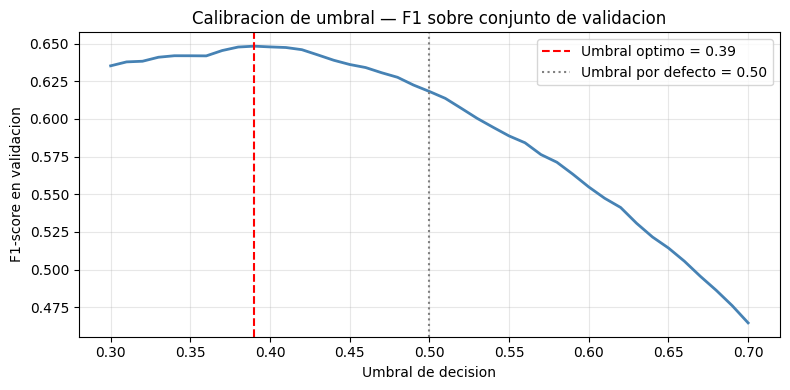

UMBRAL_OPTIMO = 0.39 se usara en la evaluacion de test.


In [23]:
print("Calibrando umbral de decision sobre el conjunto de validacion...")
print()

# Generar probabilidades sobre val
flujo_val.reset()
probs_val = mejor_modelo.predict(flujo_val, verbose=1)
probs_val = probs_val[:len(df_val)].flatten()
etiquetas_val = df_val["tiene_anomalia"].values

# Buscar el umbral que maximiza F1 en val
umbrales = np.arange(0.30, 0.71, 0.01)
f1_por_umbral = [
    f1_score(etiquetas_val, (probs_val >= u).astype(int), zero_division=0)
    for u in umbrales
]

UMBRAL_OPTIMO = float(umbrales[np.argmax(f1_por_umbral)])
f1_optimo     = max(f1_por_umbral)
f1_con_05     = f1_score(etiquetas_val, (probs_val >= 0.5).astype(int))

print(f"Umbral explorado       : 0.30 a 0.70 en pasos de 0.01")
print(f"Umbral optimo (max F1) : {UMBRAL_OPTIMO:.2f}")
print(f"F1 en val con umbral optimo : {f1_optimo:.3f}")
print(f"F1 en val con umbral 0.50   : {f1_con_05:.3f}")
print()

# Graficar curva F1 vs umbral
plt.figure(figsize=(8, 4))
plt.plot(umbrales, f1_por_umbral, color="steelblue", linewidth=2)
plt.axvline(x=UMBRAL_OPTIMO, color="red", linestyle="--",
            label=f"Umbral optimo = {UMBRAL_OPTIMO:.2f}")
plt.axvline(x=0.5, color="gray", linestyle=":",
            label="Umbral por defecto = 0.50")
plt.xlabel("Umbral de decision")
plt.ylabel("F1-score en validacion")
plt.title("Calibracion de umbral — F1 sobre conjunto de validacion")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"UMBRAL_OPTIMO = {UMBRAL_OPTIMO:.2f} se usara en la evaluacion de test.")

## Celda 16 — Matriz de confusion y metricas clinicas

Evaluacion completa sobre test usando UMBRAL_OPTIMO calibrado en val.

Metricas clinicas:
- Sensibilidad (recall): de todos los pacientes anomalos reales, que fraccion
  detecto el modelo. Un FN (anomalia no detectada) es clinicamente peligroso.
- Especificidad: de todos los pacientes normales, que fraccion identifico
  correctamente. Un FP genera alarmas innecesarias.
- Precision: de todos los que el modelo clasifico como anomalos, cuantos
  realmente lo son.
- F1-score: media armonica de precision y sensibilidad.

Comparacion con v1 y v2 al final para contextualizar el progreso.

Generando predicciones en test NIH...
636/636 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step

Matriz de confusion (test NIH, umbral=0.39):
  Verdaderos negativos (TN): 3,304  — normales correctamente identificados
  Falsos positivos    (FP): 2,562  — normales clasificados como anomalos
  Falsos negativos    (FN): 1,038  — anomalos clasificados como normales
  Verdaderos positivos (TP): 3,269  — anomalos correctamente identificados

Metricas clinicas (test NIH):
  Sensibilidad (Recall)  : 0.759
  Especificidad          : 0.563
  Precision              : 0.561
  F1-Score               : 0.645

Comparacion entre versiones (test NIH):
  Metrica        v1      v2      v3
  Sensibilidad   0.544   0.582   0.759
  Especificidad  0.790   0.756   0.563
  Precision      0.649   0.636   0.561
  F1-Score       0.592   0.608   0.645

Matriz guardada en: /content/drive/MyDrive/Vena/checkpoints/matriz_confusion_clasificacion_v3.png


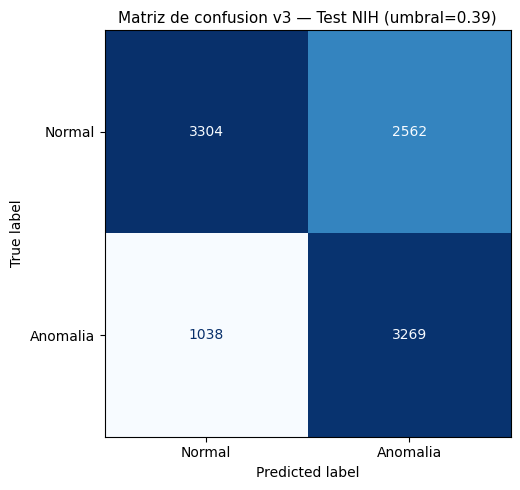


--- Validacion externa: Chest X-Ray ---
39/39 ━━━━━━━━━━━━━━━━━━━━ 6s 145ms/step
  Sensibilidad : 0.923
  Especificidad: 0.209
  (v2 tenia Sensibilidad=0.872, Especificidad=0.316 con umbral=0.50)

              precision    recall  f1-score   support

      Normal       0.62      0.21      0.31       234
    Anomalia       0.66      0.92      0.77       390

    accuracy                           0.66       624
   macro avg       0.64      0.57      0.54       624
weighted avg       0.65      0.66      0.60       624



In [24]:
# ── Predicciones en test NIH ──────────────────────────────────────────────
print("Generando predicciones en test NIH...")
flujo_test_nih.reset()
probabilidades = mejor_modelo.predict(flujo_test_nih, verbose=1)
probabilidades = probabilidades[:len(df_test_nih)]

etiquetas_reales    = df_test_nih["tiene_anomalia"].values
# Usar el umbral calibrado sobre validacion
etiquetas_predichas = (probabilidades.flatten() >= UMBRAL_OPTIMO).astype(int)

cm = confusion_matrix(etiquetas_reales, etiquetas_predichas)
tn, fp, fn, tp = cm.ravel()

print(f"\nMatriz de confusion (test NIH, umbral={UMBRAL_OPTIMO:.2f}):")
print(f"  Verdaderos negativos (TN): {tn:,}  — normales correctamente identificados")
print(f"  Falsos positivos    (FP): {fp:,}  — normales clasificados como anomalos")
print(f"  Falsos negativos    (FN): {fn:,}  — anomalos clasificados como normales")
print(f"  Verdaderos positivos (TP): {tp:,}  — anomalos correctamente identificados")

sensibilidad  = tp / (tp + fn)
especificidad = tn / (tn + fp)
precision_v   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
f1            = (2 * precision_v * sensibilidad / (precision_v + sensibilidad)
                 if (precision_v + sensibilidad) > 0 else 0.0)

print(f"\nMetricas clinicas (test NIH):")
print(f"  Sensibilidad (Recall)  : {sensibilidad:.3f}")
print(f"  Especificidad          : {especificidad:.3f}")
print(f"  Precision              : {precision_v:.3f}")
print(f"  F1-Score               : {f1:.3f}")

# Comparacion con versiones anteriores
print(f"\nComparacion entre versiones (test NIH):")
print(f"  Metrica        v1      v2      v3")
print(f"  Sensibilidad   0.544   0.582   {sensibilidad:.3f}")
print(f"  Especificidad  0.790   0.756   {especificidad:.3f}")
print(f"  Precision      0.649   0.636   {precision_v:.3f}")
print(f"  F1-Score       0.592   0.608   {f1:.3f}")

# Grafica
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Anomalia"]
)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Matriz de confusion v3 — Test NIH (umbral={UMBRAL_OPTIMO:.2f})",
             fontsize=11)
plt.tight_layout()
ruta_matriz = ruta_checkpoints / NOMBRE_MATRIZ
plt.savefig(str(ruta_matriz), dpi=150, bbox_inches="tight")
print(f"\nMatriz guardada en: {ruta_matriz}")
plt.show()

# ── Validacion externa: Chest X-Ray ──────────────────────────────────────────
print("\n--- Validacion externa: Chest X-Ray ---")
flujo_chest_test.reset()
probabilidades_chest = mejor_modelo.predict(flujo_chest_test, verbose=1)
probabilidades_chest = probabilidades_chest[:len(df_chest_test)]

etiquetas_reales_chest = df_chest_test["tiene_anomalia"].values
etiquetas_pred_chest   = (probabilidades_chest.flatten() >= UMBRAL_OPTIMO).astype(int)

cm_chest = confusion_matrix(etiquetas_reales_chest, etiquetas_pred_chest)
tn_c, fp_c, fn_c, tp_c = cm_chest.ravel()

sens_chest = tp_c / (tp_c + fn_c) if (tp_c + fn_c) > 0 else 0.0
espe_chest = tn_c / (tn_c + fp_c) if (tn_c + fp_c) > 0 else 0.0
print(f"  Sensibilidad : {sens_chest:.3f}")
print(f"  Especificidad: {espe_chest:.3f}")
print(f"  (v2 tenia Sensibilidad=0.872, Especificidad=0.316 con umbral=0.50)")
print()
print(classification_report(
    etiquetas_reales_chest, etiquetas_pred_chest,
    target_names=["Normal", "Anomalia"]
))

## Celda 17 — Guardar backbone v3

Extrae el backbone del mejor modelo y lo guarda por separado para que los
notebooks NB03 (regresion) y NB04 (clustering) puedan reutilizarlo.

El backbone tiene salida (None, 7, 7, 1024). Los notebooks que lo usen
deben agregar GlobalAveragePooling2D antes de su cabeza respectiva para
convertir ese mapa de features a un vector de 1024 dimensiones.

In [25]:
ruta_backbone_v3 = ruta_checkpoints / NOMBRE_BACKBONE

if ruta_backbone_v3.exists():
    tamano_mb = ruta_backbone_v3.stat().st_size / (1024 * 1024)
    print(f"{NOMBRE_BACKBONE} ya existe ({tamano_mb:.1f} MB). No se sobreescribe.")
    print("Para regenerarlo, borrar el archivo de Drive y volver a ejecutar esta celda.")
else:
    # Reconstruir el backbone como Model independiente
    # La capa "bn" es la ultima BatchNormalization del DenseNet antes del pooling
    try:
        capa_salida = mejor_modelo.get_layer("bn")
    except ValueError:
        # Fallback: buscar la capa anterior al GlobalAveragePooling2D
        nombres = [l.name for l in mejor_modelo.layers]
        idx_pool = next(i for i, n in enumerate(nombres) if "global_average" in n)
        capa_salida = mejor_modelo.layers[idx_pool - 1]

    backbone_v3 = Model(
        inputs=mejor_modelo.input,
        outputs=capa_salida.output,
        name="backbone_densenet121_v3"
    )
    backbone_v3.save(str(ruta_backbone_v3))
    print(f"Backbone v3 guardado en: {ruta_backbone_v3}")
    print(f"  Entrada: {backbone_v3.input_shape}")
    print(f"  Salida : {backbone_v3.output_shape}  <- agregar GlobalAveragePooling2D en NB03/NB04")

print()
print("Archivos generados por este notebook (v3):")
for archivo in sorted(ruta_checkpoints.iterdir()):
    if "v3" in archivo.name:
        tamano_mb = archivo.stat().st_size / (1024 * 1024)
        print(f"  {archivo.name} ({tamano_mb:.1f} MB)")

Backbone v3 guardado en: /content/drive/MyDrive/Vena/checkpoints/backbone_densenet121_v3.h5
  Entrada: (None, 224, 224, 3)
  Salida : (None, 7, 7, 1024)  <- agregar GlobalAveragePooling2D en NB03/NB04

Archivos generados por este notebook (v3):
  backbone_densenet121_v3.h5 (28.1 MB)
  matriz_confusion_clasificacion_v3.png (0.0 MB)
  mejor_modelo_clasificacion_v3_f1.keras (31.3 MB)
  mejor_modelo_clasificacion_v3_f2.keras (45.7 MB)
